In [1]:

#!pip install scikit-learn
!pip install torchmetrics



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [11]:
import os
import json
import time
import random
from pathlib import Path
from collections import defaultdict
import tempfile
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights
from torchvision.transforms import functional as F
from torchvision.ops import box_iou
from torch.optim import AdamW
from torchvision.transforms import Compose, ToTensor, Resize
import numpy as np
from PIL import Image
import cv2
import torch.nn as nn
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torchvision.transforms.functional as TF
from torchvision.ops import nms
from torchvision.ops import box_iou
from torchvision.ops import box_iou
from collections import defaultdict
from torch.cuda.amp import GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR
from torch.optim import SGD
from collections import defaultdict
from torchvision.ops import box_iou, nms
import torch
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.transforms import v2
from google.colab import drive



In [12]:
device = torch.device("cuda")
print(f"CUDA available: {torch.cuda.is_available()}, Device: {torch.cuda.get_device_name(0)}")

CUDA available: True, Device: NVIDIA A100-SXM4-40GB


In [13]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# Root directory setup for the balanced dataset
PROJECT_DIR = Path("/content/drive/MyDrive/Team 8 Capstone")
DATA_DIR = PROJECT_DIR / "datasets"
BALANCED_DIR = DATA_DIR / "balanced_Agroverse"
ANNOTATION_DIR = BALANCED_DIR / "Argoverse-HD" / "annotations"
IMAGE_DIR = BALANCED_DIR / "Argoverse-1.1" / "images"

BALANCED_TRAIN_JSON = ANNOTATION_DIR / "balanced_train.json"
ORIGINAL_VAL_JSON = ANNOTATION_DIR / "val.json"

TRAIN_JSON = ANNOTATION_DIR / "balanced_train_shifted.json"
VAL_JSON = ANNOTATION_DIR / "val_shifted.json"

In [15]:

# Changing all annotations to +1 for the categories to not conflict with SSD300 since it assigns 0 to background
def shift_categories(input_path, output_filename):
    with open(input_path, "r") as f:
        data = json.load(f)

    for ann in data.get("annotations", []):
        ann["category_id"] += 1

    output_path = input_path.with_name(output_filename)
    with open(output_path, "w") as f:
        json.dump(data, f, indent=2)

    print(f" Saved updated annotations to {output_path.name} (category_id +1)")

# Paths to original annotation files
train_path = BALANCED_TRAIN_JSON
val_path = ORIGINAL_VAL_JSON

# Output filenames
shifted_train_filename = "balanced_train_shifted.json"
shifted_val_filename = "val_shifted.json"

# Applying
shift_categories(train_path, shifted_train_filename)
shift_categories(val_path, shifted_val_filename)


 Saved updated annotations to balanced_train_shifted.json (category_id +1)
 Saved updated annotations to val_shifted.json (category_id +1)


In [16]:
from torch.utils.data import Dataset
from torchvision.transforms import Compose, Resize, ToTensor
from PIL import Image
from pathlib import Path
import torch
import json
from pycocotools.coco import COCO

class ArgoverseDataset(Dataset):
    def __init__(self, annotation_file, image_root, split, scale_boxes=True):
        self.coco = COCO(annotation_file)
        self.image_root = Path(image_root)
        self.split = split
        self.scale_boxes = scale_boxes

        with open(annotation_file, "r") as f:
            full_json = json.load(f)

        self.sid_to_folder = {
            sid: Path(seq).parent.name for sid, seq in enumerate(full_json["seq_dirs"])
        }

        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transform = Compose([
            Resize((300, 300)),
            ToTensor()
        ])

    def __getitem__(self, index):
        img_id = self.ids[index]
        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        if len(anns) == 0:
            return None

        img_info = self.coco.loadImgs(img_id)[0]
        file_name = img_info.get("file_name", img_info.get("name"))
        sid = img_info.get("sid")
        folder = self.sid_to_folder.get(sid)
        if folder is None:
            raise ValueError(f"SID {sid} not found in seq_dirs mapping")

        img_path = self.image_root / self.split / folder / "ring_front_center" / file_name
        img = Image.open(img_path).convert("RGB")

        orig_w, orig_h = img.size
        img_tensor = self.transform(img)

        boxes, labels = [], []
        for ann in anns:
            x, y, w, h = ann["bbox"]
            if w <= 0 or h <= 0:
                continue
            if self.scale_boxes:
                x1 = x / orig_w * 300
                y1 = y / orig_h * 300
                x2 = (x + w) / orig_w * 300
                y2 = (y + h) / orig_h * 300
            else:
                x1, y1, x2, y2 = x, y, x + w, y + h
            boxes.append([x1, y1, x2, y2])
            labels.append(ann["category_id"])

        if len(boxes) == 0:
            return None

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor(img_info["id"]),
            "file_name": file_name,
            "sid": folder,
            "iscrowd": torch.zeros(len(boxes), dtype=torch.int64)
        }

        return img_tensor, target

    def __len__(self):
        return len(self.ids)


In [17]:
# === Dataset Instantiation ===
train_dataset = ArgoverseDataset(
    annotation_file=TRAIN_JSON,
    image_root=IMAGE_DIR,
    split="train",
    scale_boxes=True,

)

val_dataset = ArgoverseDataset(
    annotation_file=VAL_JSON,
    image_root=IMAGE_DIR,
    split="val",
    scale_boxes=True
)

# === Collate Function ===
def detection_collate(batch):
    batch = [item for item in batch if item is not None]  # Filter out any invalid samples
    if len(batch) == 0:
        return [], []
    images, targets = zip(*batch)
    return list(images), list(targets)

# === DataLoaders ===
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    collate_fn=detection_collate,
    pin_memory=True,
    num_workers=10,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    collate_fn=detection_collate,
    pin_memory=True,
    num_workers=10
)


loading annotations into memory...
Done (t=6.15s)
creating index...
index created!
loading annotations into memory...
Done (t=0.79s)
creating index...
index created!


In [18]:
def visualize_sample(dataset, index=0, show_labels=True):
    img, target = dataset[index]
    img_np = TF.to_pil_image(img)

    boxes = target["boxes"]
    labels = target["labels"]
    file_name = target.get("file_name", "unknown")
    sid = target.get("sid", "unknown")

    fig, ax = plt.subplots(1, figsize=(6, 6))
    ax.imshow(img_np)
    ax.set_title(f"ID: {target['image_id'].item()} | SID: {sid} | File: {file_name}\nBoxes: {len(boxes)}")

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.tolist()
        width = x2 - x1
        height = y2 - y1

        # Skip invalid or tiny boxes
        if width <= 1 or height <= 1:
            continue

        rect = patches.Rectangle(
            (x1, y1), width, height,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)

        if show_labels:
            label = labels[i].item() if i < len(labels) else "?"
            ax.text(x1, y1 - 2, str(label), fontsize=8, color='lime', backgroundcolor="black")

    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [19]:
#train_dataset = ArgoverseDataset(TRAIN_JSON, IMAGE_DIR, split="train")

img, target = train_dataset[1]
print("Target dictionary:")
for k, v in target.items():
    print(f"{k}: {v}")


Target dictionary:
boxes: tensor([[140.1562, 146.0000, 179.5312, 203.0000],
        [ 71.7188, 106.2500, 135.4688, 196.7500],
        [ 65.0000,  68.0000,  69.2188,  86.0000],
        [102.3438,  70.7500, 106.2500,  88.5000],
        [ 32.9688,  98.7500,  36.0938, 111.7500],
        [ 47.8125, 105.5000,  50.4688, 115.2500],
        [ 27.0312, 139.5000,  52.3438, 158.2500],
        [ 57.5000, 145.7500,  67.3438, 155.5000],
        [  0.6250, 149.2500,  15.1562, 159.2500],
        [ 12.6562, 148.0000,  27.3438, 158.7500],
        [147.5000, 106.2500, 149.8438, 115.5000],
        [ 69.3750, 135.5000,  71.2500, 141.7500],
        [131.2500, 107.7500, 133.4375, 116.7500],
        [143.4375, 149.2500, 146.2500, 152.5000],
        [179.5312, 124.9987, 181.5625, 133.9987],
        [ 77.3438,  42.5000,  93.5938,  60.2500],
        [289.5312, 146.5000, 290.9375, 152.0000],
        [ 95.6250, 184.0000, 159.8438, 255.5000],
        [122.5000, 158.7500, 125.4688, 163.5000]])
labels: tensor([3, 6, 7

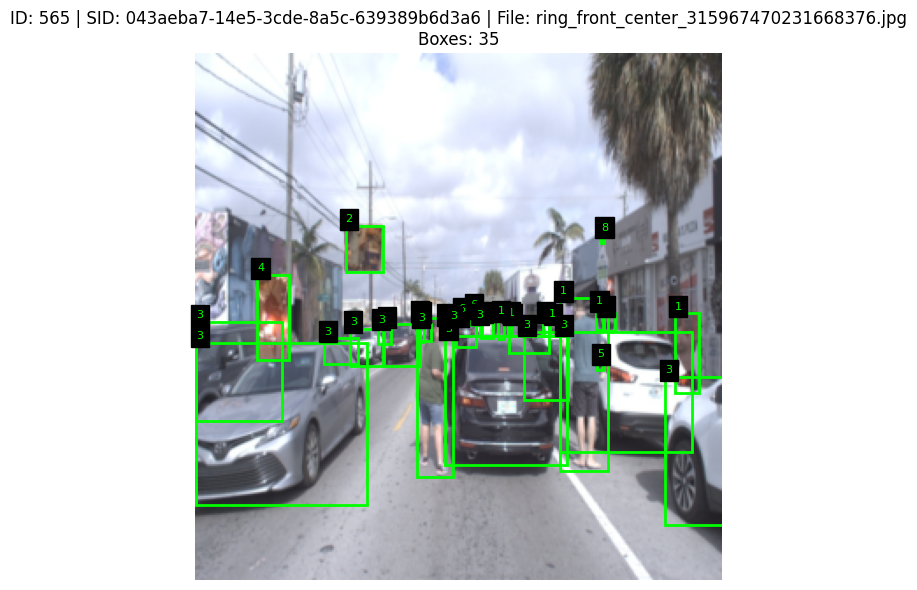

In [20]:
# Preview a specific one
visualize_sample(train_dataset, index=565)



In [21]:
img, target = train_dataset[1]
print("Image shape:", img.shape)
print("Boxes:", target["boxes"].shape)
print("Labels:", target["labels"])
print("File:", target["file_name"])


Image shape: torch.Size([3, 300, 300])
Boxes: torch.Size([19, 4])
Labels: tensor([3, 6, 7, 7, 7, 7, 6, 6, 3, 3, 7, 7, 7, 3, 7, 2, 4, 5, 8])
File: ring_front_center_315968494047328248_blurred.jpg


In [22]:
for i in range(5):
    img, target = train_dataset[i]
    print(f"[{i}] Image shape: {img.shape}, Boxes: {target['boxes'].shape}")


[0] Image shape: torch.Size([3, 300, 300]), Boxes: torch.Size([19, 4])
[1] Image shape: torch.Size([3, 300, 300]), Boxes: torch.Size([19, 4])
[2] Image shape: torch.Size([3, 300, 300]), Boxes: torch.Size([19, 4])
[3] Image shape: torch.Size([3, 300, 300]), Boxes: torch.Size([19, 4])
[4] Image shape: torch.Size([3, 300, 300]), Boxes: torch.Size([19, 4])


In [23]:
AGROVERSE_CLASS_NAMES = {
    1: "person",
    2: "bicycle",
    3: "car",
    4: "motorcycle",
    5: "bus",
    6: "truck",
    7: "traffic_light",
    8: "stop_sign"
}
COCO_CLASS_NAMES = {
    1: "person",
    2: "bicycle",
    3: "car",
    4: "motorcycle",
    6: "bus",
    8: "truck",
    10: "traffic_light",
    12: "stop_sign"
}

In [24]:
# Load pretrained SSD300
weights = SSD300_VGG16_Weights.DEFAULT
model = ssd300_vgg16(weights=weights)

# Freeze the backbone

for param in model.backbone.parameters():
    param.requires_grad = False

# Define Argoverse classes
num_classes = 9  # 8 + background
num_anchors = model.anchor_generator.num_anchors_per_location()  # [4, 6, 6, 6, 4, 4]

# Mapping from Argoverse IDs to COCO IDs
argo_to_coco = {
    0: 0,   # background → background
    1: 1,   # person → person
    2: 2,   # bicycle → bicycle
    3: 3,   # car → car
    4: 4,   # motorcycle → motorcycle
    5: 6,   # bus → bus
    6: 8,   # truck → truck
    7: 10,  # traffic_light → traffic_light
    8: 12   # stop_sign → stop_sign
}

# Adapt classification head
original_head = model.head.classification_head.module_list
new_module_list = nn.ModuleList()

for i, old_conv in enumerate(original_head):
    in_channels = old_conv.in_channels  # e.g., 512, 1024, etc.
    out_channels = num_anchors[i] * num_classes  # e.g., 4 * 9 = 36

    # New Conv2d layer
    new_conv = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

    # Transfer weights
    with torch.no_grad():
        old_weights = old_conv.weight.data  # [num_anchors[i] * 91, in_channels, 3, 3]
        new_weights = new_conv.weight.data  # [num_anchors[i] * 9, in_channels, 3, 3]
        old_bias = old_conv.bias.data
        new_bias = new_conv.bias.data

        for anchor_idx in range(num_anchors[i]):
            for argo_idx in range(num_classes):
                coco_idx = argo_to_coco[argo_idx]
                old_start = anchor_idx * 91 + coco_idx
                new_start = anchor_idx * 9 + argo_idx
                new_weights[new_start] = old_weights[old_start]
                new_bias[new_start] = old_bias[old_start]

        new_conv.weight.data = new_weights
        new_conv.bias.data = new_bias

    new_module_list.append(new_conv)

# Update the head
model.head.classification_head.module_list = new_module_list
model.head.classification_head.num_classes = num_classes
model.head.classification_head.num_columns = num_classes

# Move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Verify trainable parameters
for name, param in model.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /root/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth
100%|██████████| 136M/136M [00:00<00:00, 188MB/s]


backbone.scale_weight: requires_grad=False
backbone.features.0.weight: requires_grad=False
backbone.features.0.bias: requires_grad=False
backbone.features.2.weight: requires_grad=False
backbone.features.2.bias: requires_grad=False
backbone.features.5.weight: requires_grad=False
backbone.features.5.bias: requires_grad=False
backbone.features.7.weight: requires_grad=False
backbone.features.7.bias: requires_grad=False
backbone.features.10.weight: requires_grad=False
backbone.features.10.bias: requires_grad=False
backbone.features.12.weight: requires_grad=False
backbone.features.12.bias: requires_grad=False
backbone.features.14.weight: requires_grad=False
backbone.features.14.bias: requires_grad=False
backbone.features.17.weight: requires_grad=False
backbone.features.17.bias: requires_grad=False
backbone.features.19.weight: requires_grad=False
backbone.features.19.bias: requires_grad=False
backbone.features.21.weight: requires_grad=False
backbone.features.21.bias: requires_grad=False
backb

In [ ]:
"""
weights = SSD300_VGG16_Weights.DEFAULT
model = ssd300_vgg16(weights=weights)

num_classes = 9
num_anchors = model.anchor_generator.num_anchors_per_location()

model.head.classification_head.num_classes = num_classes
model.head.classification_head.num_columns = num_classes

dropout_p = 0.05  # Dropout probability

model.head.classification_head.module_list = nn.ModuleList([
    nn.Sequential(
        nn.Conv2d(512, num_anchors[0] * num_classes, kernel_size=3, padding=1),
        nn.Dropout2d(p=dropout_p)
    ),
    nn.Sequential(
        nn.Conv2d(1024, num_anchors[1] * num_classes, kernel_size=3, padding=1),
        nn.Dropout2d(p=dropout_p)
    ),
    nn.Sequential(
        nn.Conv2d(512, num_anchors[2] * num_classes, kernel_size=3, padding=1),
        nn.Dropout2d(p=dropout_p)
    ),
    nn.Sequential(
        nn.Conv2d(256, num_anchors[3] * num_classes, kernel_size=3, padding=1),
        nn.Dropout2d(p=dropout_p)
    ),
    nn.Sequential(
        nn.Conv2d(256, num_anchors[4] * num_classes, kernel_size=3, padding=1),
        nn.Dropout2d(p=dropout_p)
    ),
    nn.Sequential(
        nn.Conv2d(256, num_anchors[5] * num_classes, kernel_size=3, padding=1),
        nn.Dropout2d(p=dropout_p)
    ),
])

for param in model.backbone.parameters():
    param.requires_grad = False

"""

'\nfor param in model.backbone.parameters():\n    param.requires_grad = False\n    '

In [25]:
def evaluate_ssd_map(model, data_loader, device, epoch, writer):
    model.eval()
    total_cls_loss = 0.0
    total_box_loss = 0.0
    total_batches = 0

    metric = MeanAveragePrecision(
        iou_type="bbox",
        iou_thresholds=[0.5],
        max_detection_thresholds=[1, 10, 50],
        class_metrics=False
    )
    metric.warn_on_many_detections = False

    with torch.no_grad():
        for images, targets in tqdm(data_loader, desc=f"Evaluating Epoch {epoch+1}"):
            if not images or not targets:
                continue

            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

            # Get predictions
            outputs = model(images)

            # Get losses by temporarily switching to train mode
            model.train()
            loss_dict = model(images, targets)
            model.eval()

            cls_loss = loss_dict.get("classification", torch.tensor(0.0, device=device)).item()
            box_loss = loss_dict.get("bbox_regression", torch.tensor(0.0, device=device)).item()
            total_cls_loss += cls_loss
            total_box_loss += box_loss

            preds = [{"boxes": p["boxes"].detach().cpu(), "scores": p["scores"].detach().cpu(), "labels": p["labels"].detach().cpu()} for p in outputs]
            gts = [{"boxes": t["boxes"].detach().cpu(), "labels": t["labels"].detach().cpu()} for t in targets]
            metric.update(preds, gts)
            total_batches += 1

    scores = metric.compute()
    map_50 = scores["map_50"].item() if total_batches > 0 else 0.0
    avg_cls_loss = total_cls_loss / total_batches if total_batches > 0 else 0.0
    avg_box_loss = total_box_loss / total_batches if total_batches > 0 else 0.0

    writer.add_scalar("Val/Loss_Classification", avg_cls_loss, epoch)
    writer.add_scalar("Val/Loss_Box", avg_box_loss, epoch)
    writer.add_scalar("Val/mAP@0.5", map_50, epoch)

    print(f"[VAL] Epoch {epoch+1} — Cls Loss: {avg_cls_loss:.4f}, Box Loss: {avg_box_loss:.4f}, mAP@0.5: {map_50:.4f}")
    return map_50


In [26]:
from torch.optim.lr_scheduler import StepLR
from torch.nn.utils import clip_grad_norm_

# === Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")
model = model.to(device)

# === Hyperparameters ===
base_lr = 0.0003               #  Slightly reduced for safety with StepLR
weight_decay=0.01
momentum = 0.9
num_epochs = 50
patience = 10
warmup_epochs = 3

# === Optimizer ===

optimizer = AdamW(
    model.parameters(),
    lr=base_lr,
    weight_decay=weight_decay,
)
"""
optimizer = SGD(
    model.parameters(),
    lr=base_lr,
    momentum=momentum,
    weight_decay=weight_decay,
    nesterov=True
)
"""
# === Learning Rate Scheduler ===
scheduler = StepLR(optimizer, step_size=3, gamma=0.1)

# === AMP Scaler ===
scaler = torch.amp.GradScaler()

# === Logging Setup ===
train_id = "train3000"
log_dir = PROJECT_DIR/"runs/ssd_train3000"
weight_dir = log_dir / "weights"
log_file = log_dir / "train_log.json"
best_model_path = weight_dir / "best_ssd_model.pth"
last_model_path = weight_dir / "last_ssd_model.pth"

log_dir.mkdir(parents=True, exist_ok=True)
weight_dir.mkdir(parents=True, exist_ok=True)

writer = SummaryWriter(log_dir)

log_data = {
    "epochs": [],
    "total_loss": [],
    "cls_loss": [],
    "box_loss": [],
    "map_50": []
}

best_map50 = 0.0
no_improve_epochs = 0


[INFO] Using device: cuda


In [27]:
for epoch in range(num_epochs):
    model.train()
    epoch_cls_loss = 0.0
    epoch_box_loss = 0.0
    valid_batches = 0
    start = time.time()

    current_lr = optimizer.param_groups[0]["lr"]
    writer.add_scalar("LR", current_lr, epoch)

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")
    for batch_idx, (images, targets) in enumerate(pbar):
        filtered = [(img, tgt) for img, tgt in zip(images, targets) if tgt["boxes"].numel() > 0]
        if not filtered:
            continue

        images, targets = zip(*filtered)
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) if hasattr(v, "to") else v for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        loss_dict = model(images, targets)

        cls_loss = loss_dict.get("classification", torch.tensor(0.0, device=device))
        box_loss = loss_dict.get("bbox_regression", torch.tensor(0.0, device=device))
        loss = cls_loss + box_loss

        if not torch.isfinite(loss):
            print(f"[Skipped] Non-finite loss: {loss.item()}")
            continue

        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        scheduler.step()

        epoch_cls_loss += cls_loss.item()
        epoch_box_loss += box_loss.item()
        valid_batches += 1

        pbar.set_postfix({
            "loss": f"{loss.item():.3f}",
            "cls": f"{cls_loss.item():.3f}",
            "box": f"{box_loss.item():.3f}"
        })

    # Epoch summary
    if valid_batches == 0:
        print(f"[Warning] No valid batches in epoch {epoch+1}. Skipping.")
        continue

    avg_cls_loss = epoch_cls_loss / valid_batches
    avg_box_loss = epoch_box_loss / valid_batches
    total_loss = avg_cls_loss + avg_box_loss
    elapsed = time.time() - start

    print(f"\nEpoch {epoch+1}/{num_epochs} — Total Loss: {total_loss:.4f} "
          f"(cls: {avg_cls_loss:.4f}, box: {avg_box_loss:.4f}) — Time: {elapsed:.2f}s")

    writer.add_scalar("Loss/Total", total_loss, epoch)
    writer.add_scalar("Loss/Classification", avg_cls_loss, epoch)
    writer.add_scalar("Loss/Box", avg_box_loss, epoch)

    # === Eval + Checkpoint ===
    map_50 = evaluate_ssd_map(model, val_loader, device, epoch, writer)

    log_data["epochs"].append(epoch + 1)
    log_data["total_loss"].append(total_loss)
    log_data["cls_loss"].append(avg_cls_loss)
    log_data["box_loss"].append(avg_box_loss)
    log_data["map_50"].append(map_50)
    with open(log_file, "w") as f:
        json.dump(log_data, f)

    if map_50 > best_map50:
        best_map50 = map_50
        no_improve_epochs = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved best model (Epoch {epoch+1}) with mAP@0.5 = {map_50:.4f}")
    else:
        no_improve_epochs += 1
        print(f"No improvement for {no_improve_epochs} epoch(s)")

    torch.save(model.state_dict(), last_model_path)

    if no_improve_epochs >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

writer.close()


Epoch 1/50: 100%|██████████| 1524/1524 [1:12:10<00:00,  2.84s/batch, loss=7.752, cls=3.650, box=4.103]



Epoch 1/50 — Total Loss: 6.1455 (cls: 3.6117, box: 2.5338) — Time: 4330.42s


Evaluating Epoch 1: 100%|██████████| 471/471 [22:36<00:00,  2.88s/it]


[VAL] Epoch 1 — Cls Loss: 2.8241, Box Loss: 2.3423, mAP@0.5: 0.1388
Saved best model (Epoch 1) with mAP@0.5 = 0.1388


Epoch 2/50: 100%|██████████| 1524/1524 [05:27<00:00,  4.65batch/s, loss=7.752, cls=3.650, box=4.103]


...

[VAL] Epoch 3 — Cls Loss: 2.8240, Box Loss: 2.3422, mAP@0.5: 0.1388
No improvement for 2 epoch(s)


Epoch 4/50: 100%|██████████| 1524/1524 [05:41<00:00,  4.46batch/s, loss=7.752, cls=3.650, box=4.103]



Epoch 4/50 — Total Loss: 6.1443 (cls: 3.6110, box: 2.5333) — Time: 341.71s


Evaluating Epoch 4:  10%|█         | 48/471 [00:21<03:07,  2.26it/s]


KeyboardInterrupt: 

In [ ]:
# === Save final model ===
model_save_path = "/content/drive/MyDrive/Team_8_Capstone/ssd3000.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")